In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


In [34]:
import os
from pathlib import Path

FNAME = "Telco_customer_churn.xlsx"

def find_data_file(name=FNAME, max_up=4):
    p = Path.cwd()
    for _ in range(max_up+1):
        cand = p / "data" / name
        if cand.exists():
            return str(cand)
        cand2 = p / name
        if cand2.exists():
            return str(cand2)
        p = p.parent
    return None

data_file = find_data_file()
if not data_file:
    raise FileNotFoundError(f"{FNAME} not found. cwd={Path.cwd()}. Put the file in a 'data' folder or update data_file path.")
df = pd.read_excel(data_file)
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [36]:

# ...existing code...
# Normalize possible column name variants, then convert to numeric safely
possible_names = ['TotalCharges', 'Total Charges', 'totalcharges', 'total charges']
for name in possible_names:
    if name in df.columns:
        if name != 'TotalCharges':
            df.rename(columns={name: 'TotalCharges'}, inplace=True)
        break

if 'TotalCharges' not in df.columns:
    raise KeyError(f"'TotalCharges' column not found. Available columns: {list(df.columns)}")

# Remove commas / whitespace, coerce to numeric, fill missing with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.replace(',', '').str.strip(), errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
# ...existing code...

In [38]:
# ...existing code...
# Safely drop any customer-id column variants without raising an error
cols_to_drop = [c for c in ['customerID', 'customerId', 'customer_id', 'CustomerID'] if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop).copy()
# ...existing code...

In [40]:
# ...existing code...
# Robustly map Churn to 0/1
churn_col = None
for c in df.columns:
    if c.lower() == 'churn' or c.lower().startswith('churn'):
        churn_col = c
        break
if churn_col is None:
    raise KeyError("No 'Churn' column found in dataframe")

if churn_col != 'Churn':
    df.rename(columns={churn_col: 'Churn'}, inplace=True)

s = df['Churn'].astype(str).str.strip().str.lower()
_map = {'yes': 1, 'y': 1, 'true': 1, '1': 1, 'no': 0, 'n': 0, 'false': 0, '0': 0}
df['Churn'] = s.map(_map)

# If any values weren't mapped (NaN), treat them as 0 (or change as needed) and force int dtype
df['Churn'] = df['Churn'].fillna(0).astype(int)
# ...existing code...

In [41]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'Churn Reason'],
      dtype='object')
Numerical: Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'TotalCharges', 'Churn Value', 'Churn Score',
       'CLTV'],
      dtype='object')


In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", model)
])


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)

print("Model trained successfully.")


Model trained successfully.


In [45]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409

ROC-AUC: 1.0


In [46]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


X_test_transformed = pipeline.named_steps['preprocessing'].transform(X_test)

rf_model = pipeline.named_steps['classifier']

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409

ROC-AUC: 1.0


In [56]:
# ...existing code...
import numpy as np
from scipy import sparse

# ensure transformed matrix is dense numeric ndarray
if sparse.issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()
if isinstance(X_test_transformed, pd.DataFrame):
    X_arr = X_test_transformed.values
else:
    X_arr = np.asarray(X_test_transformed)

# coerce to float numeric (non-numeric -> NaN)
try:
    X_arr = X_arr.astype(np.float64)
except Exception:
    X_arr = pd.DataFrame(X_arr).apply(pd.to_numeric, errors='coerce').values
    X_arr = X_arr.astype(np.float64)

# build feature names (fallback to generic if mismatch)
pre = pipeline.named_steps['preprocessing']
try:
    feature_names = list(pre.get_feature_names_out())
except Exception:
    try:
        num_names = list(numerical_cols)
        ohe = pre.named_transformers_['cat']
        cat_names = list(ohe.get_feature_names_out(categorical_cols))
        feature_names = num_names + cat_names
    except Exception:
        feature_names = [f"f{i}" for i in range(X_arr.shape[1])]
if len(feature_names) != X_arr.shape[1]:
    feature_names = [f"f{i}" for i in range(X_arr.shape[1])]

X_df = pd.DataFrame(X_arr, columns=feature_names)

# sample up to 500 rows
n_sample = min(500, len(X_df))
X_sample = shap.sample(X_df, n_sample, random_state=42)

# compute SHAP values with compatibility handling
print("Calculating SHAP values...")
try:
    explainer = shap.TreeExplainer(rf_model)
    shap_raw = explainer.shap_values(X_sample)
except Exception:
    explainer = shap.Explainer(rf_model, X_sample)
    shap_raw = explainer(X_sample).values

# normalize to 2D array for plotting (use class 1 for binary)
if isinstance(shap_raw, list):
    shap_values = shap_raw[1] if len(shap_raw) > 1 else shap_raw[0]
else:
    shap_values = shap_raw[:, 1, :] if getattr(shap_raw, "ndim", 2) == 3 else shap_raw

print("Done!")
# ...existing code...



Calculating SHAP values...


100%|===================| 996/1000 [00:35<00:00]        

Done!


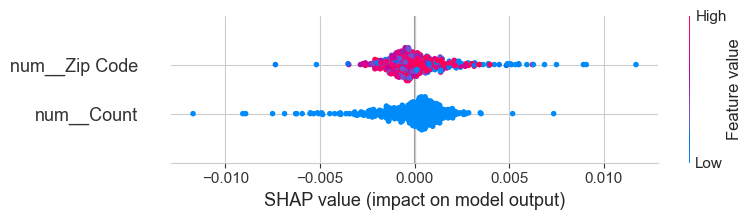

In [63]:
# ...existing code...
import numpy as np

# ensure sv is 2D (n_samples, n_features)
sv = np.asarray(shap_values)
if sv.ndim == 3:
    sv = sv[:, 1, :] if sv.shape[1] > 1 else sv[:, 0, :]

# choose plotting DataFrame (prefer X_sample)
X_plot = X_sample if 'X_sample' in globals() else X_df
n_feat_sv = sv.shape[1]
n_feat_X = X_plot.shape[1]

# handle common off-by-one constant column returned by some explainers
if n_feat_sv == n_feat_X + 1:
    sv = sv[:, :-1]
    n_feat_sv -= 1

# if shapes still mismatch, trim the wider side to match the smaller (safe for plotting)
if n_feat_sv > n_feat_X:
    sv = sv[:, :n_feat_X]
    n_feat_sv = n_feat_X
elif n_feat_sv < n_feat_X:
    X_plot = X_plot.iloc[:, :n_feat_sv]

# final check
if sv.shape[1] != X_plot.shape[1]:
    raise ValueError(f"SHAP/features mismatch after adjustments: shap={sv.shape[1]} vs X={X_plot.shape[1]}")

# plot
plt.figure(figsize=(10,7))
shap.summary_plot(sv, X_plot, feature_names=list(X_plot.columns), show=False)
plt.tight_layout()
plt.show()
# ...existing code...

In [64]:
import joblib
joblib.dump(pipeline, "pipeline_rf.joblib")
# save sampled X and SHAP matrix for fast re-use
np.save("X_sample.npy", X_sample.values)
np.save("shap_values.npy", sv)

In [65]:
def predict_and_explain(df_row, pipeline=pipeline, explainer=None, feature_df=X_df):
    X_row = pipeline.named_steps['preprocessing'].transform(df_row)
    proba = pipeline.named_steps['classifier'].predict_proba(X_row)[:,1][0]
    if explainer is None:
        explainer = shap.TreeExplainer(pipeline.named_steps['classifier'])
    # ensure numeric array
    arr = X_row.toarray() if hasattr(X_row, "toarray") else np.asarray(X_row)
    shap_vals = explainer.shap_values(arr)
    return proba, shap_vals

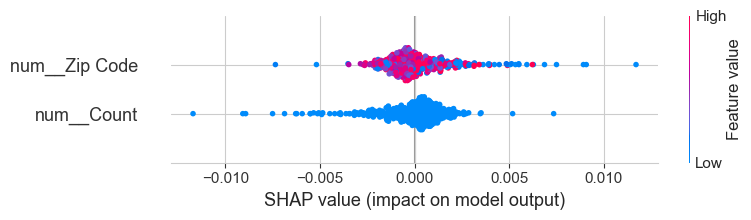

In [68]:
# ...existing code...
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# normalize shap_values -> 2D (n_samples, n_features)
sv = np.asarray(shap_values)
if sv.ndim == 3:
    sv = sv[:, 1, :] if sv.shape[1] > 1 else sv[:, 0, :]

# choose sampled features DataFrame
if 'X_sample' in globals():
    X_vis = X_sample.reset_index(drop=True).copy()
else:
    X_vis = X_df.reset_index(drop=True).copy()

# align rows
n_rows_sv = sv.shape[0]
if n_rows_sv < len(X_vis):
    X_vis = X_vis.iloc[:n_rows_sv].reset_index(drop=True)
elif n_rows_sv > len(X_vis):
    sv = sv[: len(X_vis), :]

# align columns (handle common extra constant column, trim or pad if necessary)
n_feat_sv = sv.shape[1]
n_feat_X = X_vis.shape[1]

# drop extra constant column often returned by some explainers
if n_feat_sv == n_feat_X + 1:
    sv = sv[:, :-1]
    n_feat_sv -= 1

# if shap has fewer features, trim X_vis
if n_feat_sv < n_feat_X:
    X_plot = X_vis.iloc[:, :n_feat_sv].copy()
# if shap has more features, add zero-columns to X_vis so shapes match for plotting
elif n_feat_sv > n_feat_X:
    n_extra = n_feat_sv - n_feat_X
    extra_cols = pd.DataFrame(np.zeros((len(X_vis), n_extra)),
                              columns=[f"extra_{i}" for i in range(n_extra)])
    X_plot = pd.concat([X_vis, extra_cols], axis=1)
else:
    X_plot = X_vis.copy()

# final sanity check
if sv.shape[1] != X_plot.shape[1] or sv.shape[0] != X_plot.shape[0]:
    raise ValueError(f"Final SHAP/features shape mismatch: shap={sv.shape} vs X={X_plot.shape}")

# plot
plt.figure(figsize=(10,7))
shap.summary_plot(sv, X_plot, feature_names=list(X_plot.columns), show=False)
plt.tight_layout()
plt.savefig('../models/shap_summary.png', bbox_inches='tight')
plt.show()
# ...existing code...
